In [53]:
import pandas as pd
import numpy as np

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [54]:
df = pd.read_csv(r"C:\Users\dines\Downloads\Business_Analytics\final_text_mining_dataset.csv")


df.head()

df["Airline"].value_counts()

Airline
Caribbean Airlines           100
GoAir                        100
Germanwings                  100
Philippine Airlines          100
Bangkok Airways              100
                            ... 
JC International Airlines      1
MEGA Maldives Airlines         1
MAYAir                         1
Tibet Airlines                 1
Dimonim Air                    1
Name: count, Length: 497, dtype: int64

In [55]:
indian_airlines = ["Indigo", "Air India", "Akasa", "SpiceJet", "Vistara"]

# Count and sort original airlines
airline_counts = df["Airline"].value_counts()

# Split airlines into 5 nearly equal buckets
buckets = np.array_split(airline_counts.index.tolist(), len(indian_airlines))

# Create mapping dictionary
airline_mapping = {}

for i, bucket in enumerate(buckets):
    for airline in bucket:
        airline_mapping[airline] = indian_airlines[i]

# Apply mapping
df["Airline"] = df["Airline"].map(airline_mapping)

df["Airline"].value_counts()

Airline
Indigo       10000
Air India     8822
Akasa         3287
SpiceJet       876
Vistara        186
Name: count, dtype: int64

In [56]:
# Sanity checks after airline mapping
print("Unique airlines:", df["Airline"].unique())
print("\nAirline distribution:\n", df["Airline"].value_counts())
print("\nSentiment distribution:\n", df["Sentiment"].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Unique airlines: ['Vistara' 'Air India' 'SpiceJet' 'Indigo' 'Akasa']

Airline distribution:
 Airline
Indigo       10000
Air India     8822
Akasa         3287
SpiceJet       876
Vistara        186
Name: count, dtype: int64

Sentiment distribution:
 Sentiment
Positive    12423
Negative    10257
Neutral       491
Name: count, dtype: int64

Missing values:
 Review_Text    0
Airline        0
Rating         0
Sentiment      0
dtype: int64


In [57]:
airline_dummies = pd.get_dummies(df["Airline"], prefix="Airline")

airline_dummies.head()
airline_dummies.sum().sort_values(ascending=False)



Airline_Indigo       10000
Airline_Air India     8822
Airline_Akasa         3287
Airline_SpiceJet       876
Airline_Vistara        186
dtype: int64

In [58]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# If not already downloaded
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# Create Clean_Review column
df["Clean_Review"] = df["Review_Text"].apply(clean_text)

df[["Review_Text", "Clean_Review"]].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Review_Text,Clean_Review
0,Moroni to Moheli. Turned out to be a pretty ...,moroni moheli turned pretty decent airline onl...
1,Moroni to Anjouan. It is a very small airline...,moroni anjouan small airline ticket advised tu...
2,Anjouan to Dzaoudzi. A very small airline an...,anjouan dzaoudzi small airline airline based c...
3,Please do a favor yourself and do not fly wi...,please favor fly adria route munich pristina j...
4,Do not book a flight with this airline! My fr...,book flight airline friend returned sofia amst...


In [59]:
df["Clean_Length"] = df["Clean_Review"].apply(lambda x: len(x.split()))
df = df[df["Clean_Length"] > 3]

X_text = df["Clean_Review"]
y = df["Sentiment"]

X_text.shape, y.shape

((23170,), (23170,))

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

X_text_tfidf = tfidf.fit_transform(X_text)

X_text_tfidf.shape


(23170, 5000)

In [61]:
airline_dummies_final = pd.get_dummies(df["Airline"], prefix="Airline")

airline_dummies_final.shape


(23170, 5)

In [62]:
from scipy.sparse import hstack

X_final = hstack([X_text_tfidf, airline_dummies_final.values])

X_final.shape


(23170, 5005)

In [63]:
y_final = y

df["Sentiment"] = df["Sentiment"].replace("Neutral", "Positive")

df["Sentiment"].value_counts(normalize=True)
y_final = df["Sentiment"]


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

X_train.shape, X_test.shape


((18536, 5005), (4634, 5005))

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.853258523953388

Classification Report:

              precision    recall  f1-score   support

    Negative       0.81      0.88      0.84      2051
    Positive       0.90      0.83      0.86      2583

    accuracy                           0.85      4634
   macro avg       0.85      0.86      0.85      4634
weighted avg       0.86      0.85      0.85      4634



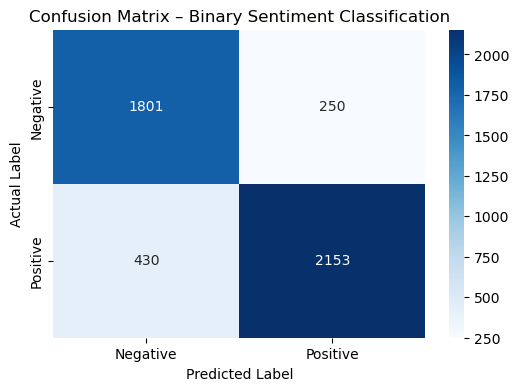

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Positive"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Binary Sentiment Classification")
plt.show()


In [67]:
# Get feature names from TF-IDF
tfidf_features = tfidf.get_feature_names_out()

# Airline feature names
airline_features = airline_dummies_final.columns.tolist()

# Combine all feature names
all_features = list(tfidf_features) + airline_features


coefficients = log_reg.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
})


In [68]:
#top negative words 
feature_importance.sort_values(
    by="Coefficient",
    ascending=True
).head(20)


,Feature,Coefficient
4913,worst,-8.868790
3768,rude,-6.294827
450,bad,-5.943130
4386,terrible,-5.444075
3405,poor,-5.411957
1191,delay,-4.740642
2252,horrible,-4.573550
4684,unprofessional,-4.104699
1196,delayed,-4.087796
712,cancelled,-3.880845


In [69]:
#top positive words 
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(20)


,Feature,Coefficient
2086,good,8.280197
2126,great,6.748815
1970,friendly,6.534125
1953,free,6.210245
3040,nice,5.662946
942,comfortable,5.565061
1535,excellent,5.486789
527,best,5.374950
530,better,4.614317
3378,pleasant,4.563967


In [70]:
#airline wise sentiment analysis for Business analytics 
airline_sentiment = (
    df.groupby(["Airline", "Sentiment"])
      .size()
      .unstack()
      .fillna(0)
)

airline_sentiment

airline_sentiment_pct = airline_sentiment.div(
    airline_sentiment.sum(axis=1),
    axis=0
) * 100

airline_sentiment_pct

Sentiment,Negative,Positive
Airline,,
Air India,43.770548,56.229452
Akasa,37.207180,62.792820
Indigo,47.970000,52.030000
SpiceJet,36.757991,63.242009
Vistara,29.032258,70.967742


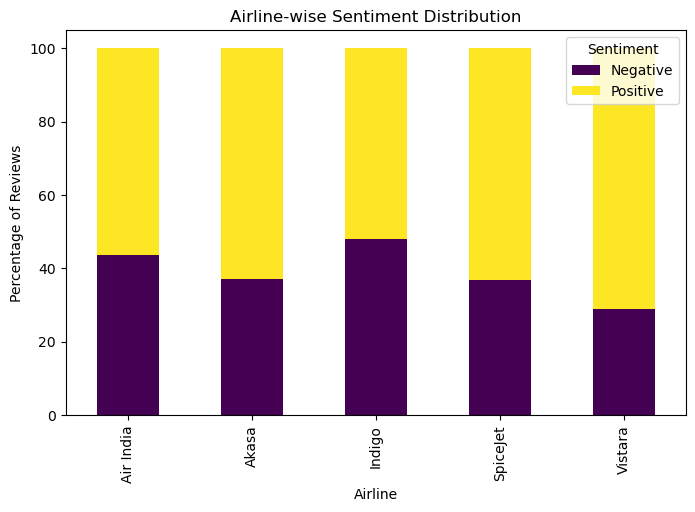

In [71]:
airline_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="viridis"
)

plt.ylabel("Percentage of Reviews")
plt.title("Airline-wise Sentiment Distribution")
plt.legend(title="Sentiment")
plt.show()


In [72]:
final_df = df.copy()

final_df.to_csv(
    "final_indian_airlines_text_mining_dataset.csv",
    index=False
)

print("Dataset saved successfully!")


Dataset saved successfully!
